In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers , models

In [6]:
(dataset_train , dataset_test) , info = tfds.load(
    "pneumonia_mnist",
    split=["train[:80]" , "test[80:]"],
    as_supervised=True,
    with_info=True
)

In [7]:
def preprocess(image , label):
  image = tf.image.resize(image , (150,150))
  image = image / 255
  return image , label

In [8]:
train_dataset = dataset_train.map(preprocess).batch(32)
test_dataset = dataset_test.map(preprocess).batch(32)

In [16]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.fit(train_dataset , epochs=3)

Epoch 1/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5750 - loss: 0.7044
Epoch 2/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5750 - loss: 0.6599
Epoch 3/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7000 - loss: 0.5946


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Normal


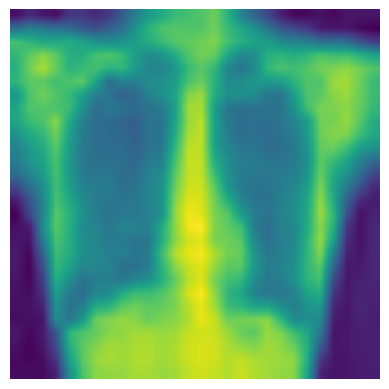

In [22]:
for image , label in test_dataset.take(1):
  prediction = model.predict(image)
  plt.imshow(image[8])
  plt.axis("off")

  if prediction[8] > 0.5:
    print("Normal")
  else:
    print("Pneumonia")